# House Price Prediction

## Project Overview

This project analyzes residential housing data and develops machine learning models to predict house sale prices.

The analysis focuses on understanding the factors associated with house prices and comparing regression models for price prediction.

### Objectives

- Understand the structure of the housing dataset
- Explore factors associated with house prices
- Perform data cleaning and preprocessing
- Analyze relationships between housing characteristics and SalePrice
- Build regression models
- Compare Linear Regression and Random Forest
- Evaluate model performance using MAE, RMSE, and R²

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
df = pd.read_csv("/content/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 1460
Jumlah kolom: 81


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df[["SalePrice", "OverallQual", "GrLivArea", "YearBuilt"]].head()

,SalePrice,OverallQual,GrLivArea,YearBuilt
0,208500,7,1710,2003
1,181500,6,1262,1976
2,223500,7,1786,2001
3,140000,7,1717,1915
4,250000,8,2198,2000


In [ ]:
df.shape

(1460, 81)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
missing_values = df.isnull().sum()

missing_values = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

missing_values.head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
df["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


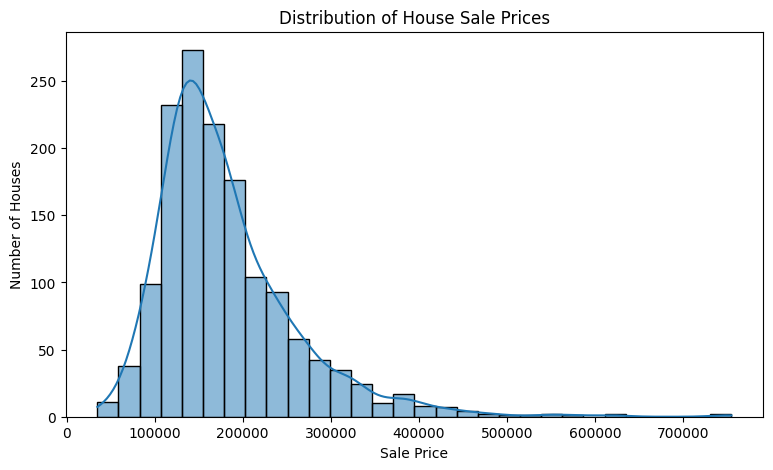

In [ ]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="SalePrice",
    bins=30,
    kde=True
)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

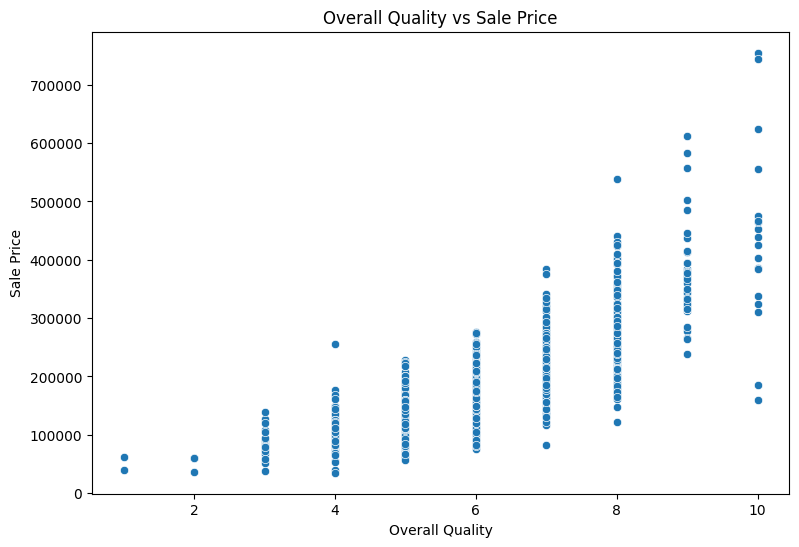

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

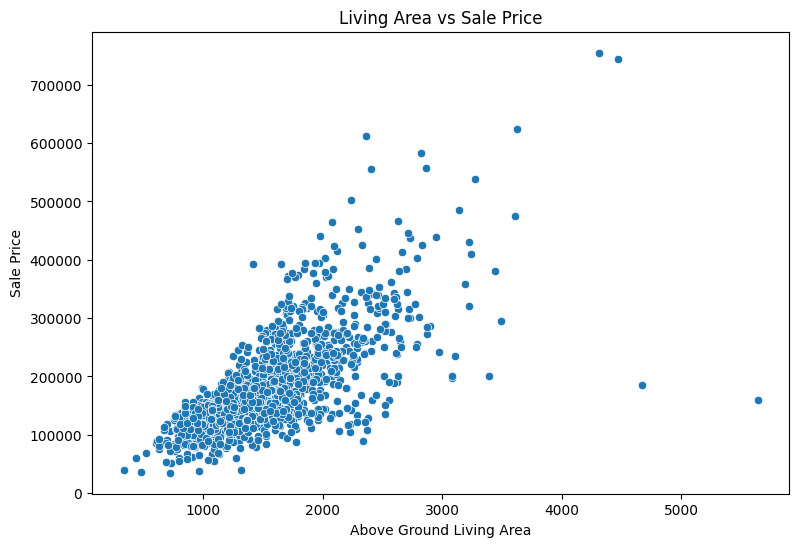

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

In [ ]:
df.shape

(1460, 81)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
missing_values.head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
selected_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "TotRmsAbvGrd"
]

df_model = df[selected_features + ["SalePrice"]].copy()

df_model.head()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,YearBuilt,FullBath,TotRmsAbvGrd,SalePrice
0,7,1710,2,548,856,856,2003,2,8,208500
1,6,1262,2,460,1262,1262,1976,2,6,181500
2,7,1786,2,608,920,920,2001,2,6,223500
3,7,1717,3,642,756,961,1915,1,7,140000
4,8,2198,3,836,1145,1145,2000,2,9,250000


In [ ]:
df_model.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0
FullBath,0
TotRmsAbvGrd,0
SalePrice,0


In [ ]:
for col in selected_features:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())

In [ ]:
df_model.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0
FullBath,0
TotRmsAbvGrd,0
SalePrice,0


In [ ]:
df_model.describe()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,YearBuilt,FullBath,TotRmsAbvGrd,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,472.980137,1057.429452,1162.626712,1971.267808,1.565068,6.517808,180921.195890
std,1.382997,525.480383,0.747315,213.804841,438.705324,386.587738,30.202904,0.550916,1.625393,79442.502883
min,1.000000,334.000000,0.000000,0.000000,0.000000,334.000000,1872.000000,0.000000,2.000000,34900.000000
25%,5.000000,1129.500000,1.000000,334.500000,795.750000,882.000000,1954.000000,1.000000,5.000000,129975.000000
50%,6.000000,1464.000000,2.000000,480.000000,991.500000,1087.000000,1973.000000,2.000000,6.000000,163000.000000
75%,7.000000,1776.750000,2.000000,576.000000,1298.250000,1391.250000,2000.000000,2.000000,7.000000,214000.000000
max,10.000000,5642.000000,4.000000,1418.000000,6110.000000,4692.000000,2010.000000,3.000000,14.000000,755000.000000


In [ ]:
correlation = (
    df_model.corr()["SalePrice"]
    .sort_values(ascending=False)
)

correlation

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


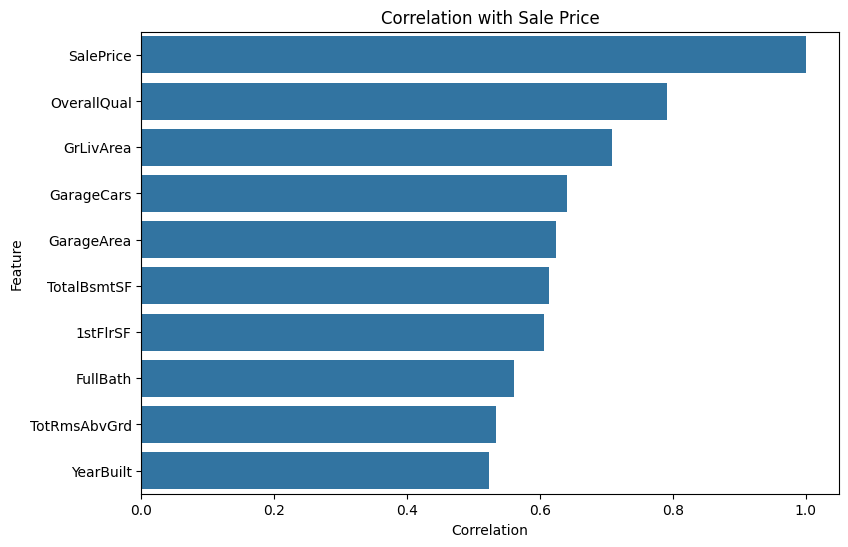

In [ ]:
plt.figure(figsize=(9,6))

sns.barplot(
    x=correlation.values,
    y=correlation.index
)

plt.title("Correlation with Sale Price")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

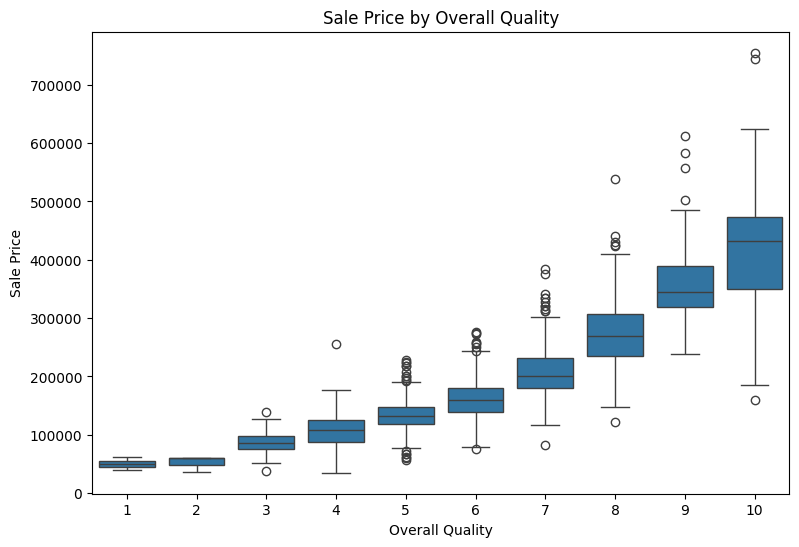

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df_model,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Sale Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

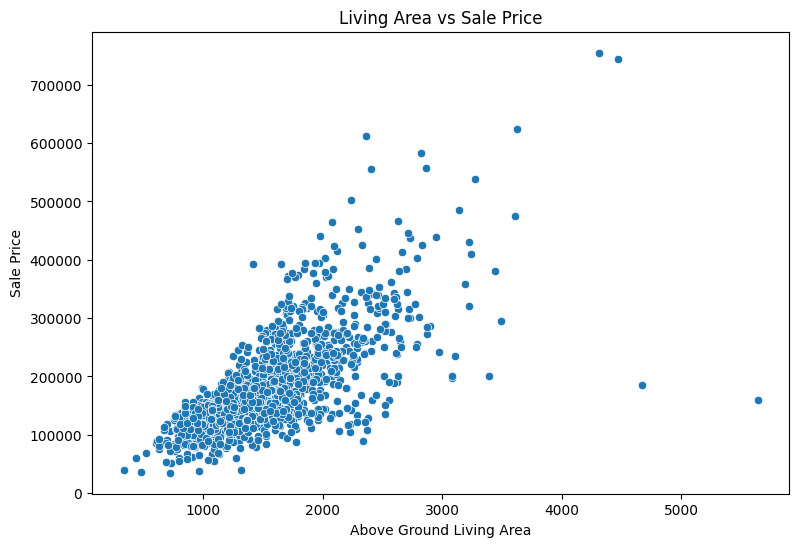

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_model,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

## 4. Machine Learning

Two regression models will be developed to predict house sale prices: Linear Regression as a baseline model and Random Forest Regression as a non-linear comparison model.

In [ ]:
X = df_model[selected_features]
y = df_model["SalePrice"]

In [ ]:
print("Jumlah fitur:", X.shape[1])
print("Jumlah target:", y.shape[0])

Jumlah fitur: 9
Jumlah target: 1460


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1168, 9)
Testing : (292, 9)


In [ ]:
df_model.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
YearBuilt,0
FullBath,0
TotRmsAbvGrd,0
SalePrice,0


In [ ]:
correlation

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


## 5. Linear Regression

Linear Regression is used as the baseline regression model to predict house sale prices from selected housing features.

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_linear = linear_model.predict(X_test)

In [ ]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print(f"MAE  : ${mae_linear:,.2f}")
print(f"RMSE : ${rmse_linear:,.2f}")
print(f"R²   : {r2_linear:.4f}")

MAE  : $24,935.83
RMSE : $39,568.64
R²   : 0.7959


## 6. Random Forest Regression

Random Forest Regression is used as a non-linear comparison model to determine whether a tree-based ensemble can provide better house price predictions than Linear Regression.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  : ${mae_rf:,.2f}")
print(f"RMSE : ${rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

MAE  : $19,082.67
RMSE : $29,738.16
R²   : 0.8847


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,24935.833234,39568.644646,0.795879
1,Random Forest,19082.672068,29738.162101,0.884704


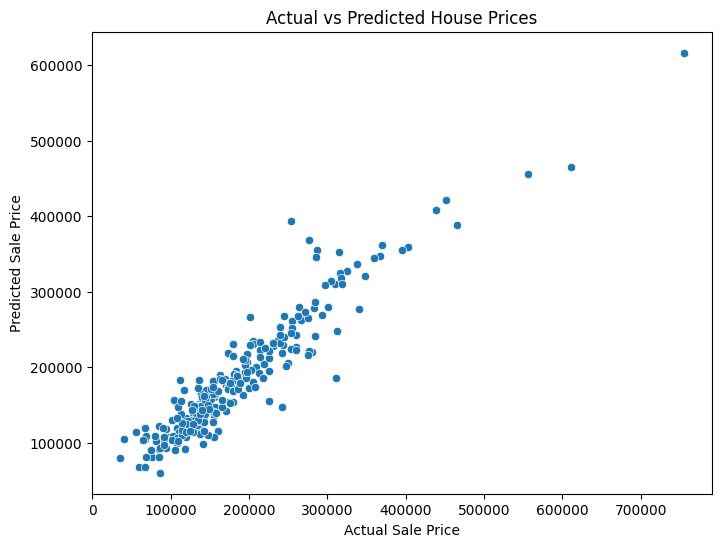

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

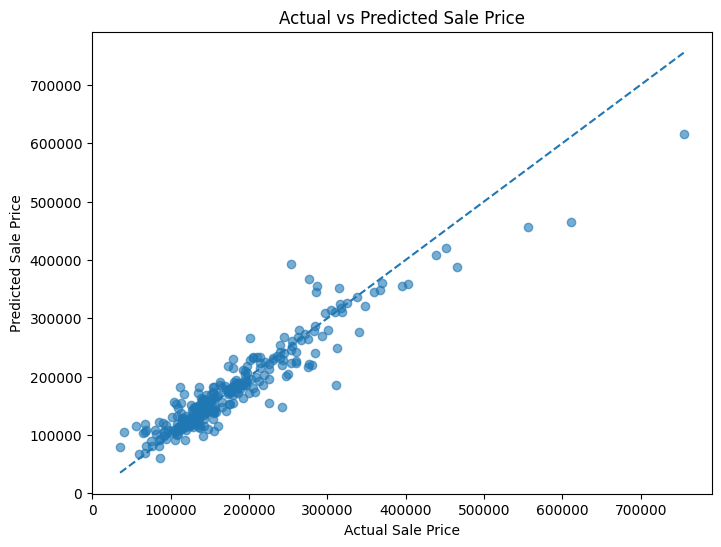

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()

In [ ]:
mae_linear
rmse_linear
r2_linear

0.7958786110456303

In [ ]:
mae_rf
rmse_rf
r2_rf

0.8847039537515928

In [ ]:
model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,24935.833234,39568.644646,0.795879
1,Random Forest,19082.672068,29738.162101,0.884704


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
)

feature_importance

,Feature,Importance
0,OverallQual,0.572325
1,GrLivArea,0.171195
4,TotalBsmtSF,0.069206
5,1stFlrSF,0.053176
6,YearBuilt,0.046788
3,GarageArea,0.037872
2,GarageCars,0.022022
8,TotRmsAbvGrd,0.016007
7,FullBath,0.011410


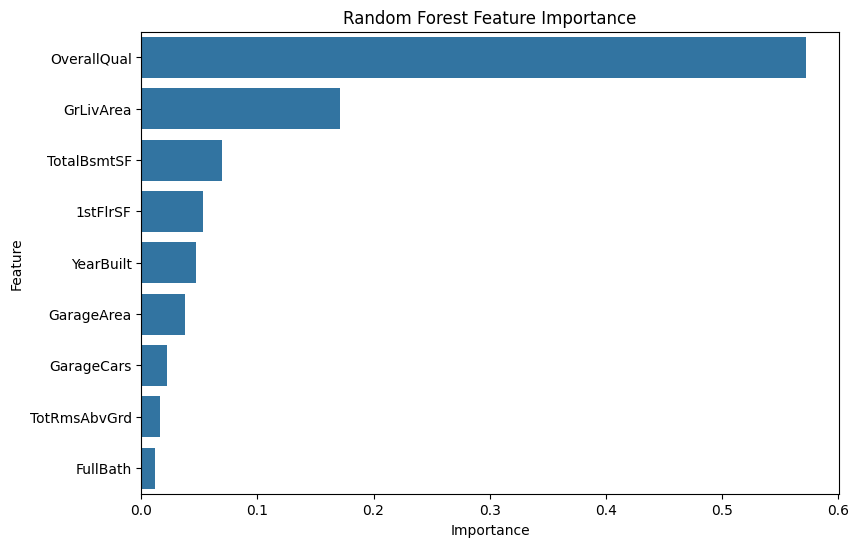

In [ ]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 7. Key Findings

### 1. Price Relationship

OverallQual had the strongest correlation with SalePrice among the selected features, with a correlation coefficient of approximately 0.79. GrLivArea was the second strongest feature with a correlation of approximately 0.71.

### 2. Linear Regression Performance

Linear Regression achieved an MAE of approximately $24,935.83, an RMSE of approximately $39,568.64, and an R² of 0.7959.

### 3. Random Forest Performance

Random Forest achieved an MAE of approximately $19,082.67, an RMSE of approximately $29,738.16, and an R² of 0.8847.

### 4. Model Comparison

Random Forest outperformed Linear Regression across all evaluation metrics. It produced a lower MAE and RMSE and a higher R².

### 5. Feature Importance

OverallQual was the most influential feature in the Random Forest model, with an importance value of approximately 0.57. GrLivArea was the second most important feature with an importance of approximately 0.17.

### 6. Main Prediction Factors

The feature importance analysis indicates that overall house quality and above-ground living area were the two most influential selected characteristics for predicting SalePrice in the Random Forest model.

## 8. Conclusion

This project analyzed residential housing characteristics and developed machine learning models to predict house sale prices.

The exploratory analysis showed that OverallQual had the strongest relationship with SalePrice among the selected features, followed by GrLivArea. These results were also supported by the Random Forest feature importance analysis.

Two regression models were evaluated: Linear Regression and Random Forest Regression. Random Forest achieved better performance with an MAE of approximately $19,082.67, an RMSE of approximately $29,738.16, and an R² of 0.8847. Linear Regression achieved an MAE of approximately $24,935.83, an RMSE of approximately $39,568.64, and an R² of 0.7959.

Based on the evaluation results, Random Forest was selected as the final model. The model indicates that OverallQual and GrLivArea were the most influential selected features in predicting house sale prices.

Overall, this project demonstrates how exploratory data analysis, feature selection, and regression models can be combined to analyze housing data and generate predictive insights.